In [Part 1](../bayesian-modelling-part-1/index.html), we got an introduction to probabilistic bayesian models and how it differs from traditional machine learning. Now, we will apply the bayesian approach of modelling to a business problem that was introduced in [Part 1](../bayesian-modelling-part-1/index.html). 


## The Traditional ML vs. Bayesian Approach Workflow
For most of us working in traditional machine learning, the workflow is very clearly defined. 

```
 Data → Features → Model → Evaluate → Improve → Deploy → Monitor
```

1) Understand the business problem
    - What are you trying to solve? What are the business metrics and technical metrics you need to optimise?
2) Data Ingestion Pipeline:
    - Identify the various data sources
    - Get data from various sources like databases, API's, scraping etc 
    - Perform EDA(Exploratory Data Analysis) i.e understand the data and how it relates to the business problem and what we're trying to solve, explore/visualize data distributions, find outliers, etc
3) Data Cleaning / Pre-processing Pipeline:
    - Handle missing values in data, remove duplicate data, convert data types, convert data into correct categories (example - encode categorical data into numeric data ), etc
    - Scale or normalise data 
4) Feature Engineering:
    - Create new features - either by using business logic 
    - Select features with highest predictive value 
    - Drp redundant features
5) Train Model:
    - Split the data into training (~70%), validation(~10%), test set(~20%) depending on the use case
    - Train model on the training data (start wth a simple classifier/model to create a baseline model and gradually increase complexity and evaluate model performance)
6) Model Evaluation:
    - Measure performance on validation sets, finetune hyperparamaeters, etc
    - Report performance metrics depending on the business problem like AUC, accuracy, etc
7) Model Deployment and Monitoring:
    - Deploy the model - through an API service, etc
    - Serve predictions and monitor performance measuring for data drift, model drift
    - Re-training model on new data

In traditional machine learning, there's a linear progression from observations/data to training model and deploying it in production i.e the data comes first and validation takes place at the end. 

But Bayesian modeling turns this paradigm on its head, demanding something that initially feels counterintuitive i.e understanding your data-generating mechanism before you even touch the real data. This approach, championed by researchers like Michael Betancourt in his principled Bayesian workflow, treats simulation not as an afterthought, but as the foundation of robust model development.

To see it action, we will go through a real world example. 

## A Real World Business Problem
In part1, we briefly discussed the business problem which seems particularly well suited for the bayesian approach.

Here's the problem statement:

Imagine you're working for an game app development platform facing a complex business problem. Your marketing team needs to identify potential users to target, but you're dealing with intricate hierarchical relationships across multiple dimensions:

- Operating Systems: iOS and Android with different user behaviors
- Device Types: iPhone, iPad, Samsung, Huawei, Nokia with varying engagement patterns
- Software Versions: Multiple versions within each device type
- Geographic Markets: Different countries with distinct economic patterns
- Revenue Dynamics: Complex relationships between device types, markets, and monetization

Your goal is to predict revenue from app installations. 

### Data Exploration
After exploring the data, there weer a few things that jumped at me,

1) the hierarchical relationships in the data  and 
2) the cold start problem, i.e there are subsets of the data which has low sample sizes and others have large sample sizes. These situations are not somehow unique to this problem - it occurs quite often in many machine learning problems. 

But traditional ML approaches struggle with this hierarchical complexity and cold-start scenarios where new device types or markets have limited historical data.

### Why Understanding Data Generation Matters
As Betancourt emphasizes in his principled workflow, a probabilistic model is only as useful as its consistency with the underlying data-generating process. Before building any model, we need to answer some fundamental questions:

- What generates the hierarchical structure? How do users choose between iOS and Android? How does device preference vary by geography?
- What drives revenue patterns? Why do iPhone users generate different revenue than Samsung users? How do country-specific economic factors influence spending?
- What creates the dependency relationships? How does software version adoption relate to device type? How do market dynamics influence user behavior?

Without understanding these mechanisms, we're building models on weak foundations. This is why it's crucial to do a thorough data exploration, analysis and talk to the subject matter domain experts and incorporate their intuition and understanding in our modelling approach. 

### The Simulation-First Approach: Building from the Ground Up
Rather than jumping directly to modelling with real data, the Bayesian approach starts with explicit data-generating mechanisms to generate simulated data and build models first on them before using any real data. Simulating a dataset is not as easy as it sounds - the first critical step is what we do for traditional machine learning development - EDA (exploratory data analysis). We need to have a strong understanding of the various features, their distributions, how the features correlate or interact with each other, how the data gets generated, etc. Once you have a solid grasp of the data generating mechanism, you can start simulating the data. 

Let's examine how this works in practice using our game app platform scenario. First, a quick glimpse of the real data provided by the business. We won't walk through the exploration of the real data here; assume that has already been done. The insights learned from it, together with business/domain knowledge from SMEs, have been built into the simulated data. In this post we explore the simulated data and confirm that its patterns match what we saw in the real data. The bayesian model is then fitted to the simulated data first (in [Part 3](../bayesian-modelling-part-3/index.html)). 


In [ ]:
import pandas as pd
import csv
from lib.data_helper_utilities import SimulatedDataGenerator
from lib.data_helper_utilities import get_configs

# sim_df = SimulatedDataGenerator.generate_simulated_data()
# sim_df.head()
configurations_filepath = "<your_config_filepath>"
configs = get_configs(configurations_filepath + 'configs.yaml')
real_df = pd.read_csv(
    configs['input_data_filepath'] + 'training_data.csv',
    delimiter=';',
    quoting=csv.QUOTE_NONE,  # some deviceType values contain stray quote characters
    on_bad_lines='skip',
    encoding_errors='replace'
)

# deviceType column contains embedded tabs (e.g. "iPhone8\t2" → "iPhone8,2")
real_df['deviceType'] = real_df['deviceType'].str.replace('\t', ',', regex=False)
real_df = real_df[["id","campaignId","timestamp","country","platform","softwareVersion","deviceType","connectionType","installCount","revenue","discount"]]
print("Shape of real dataset = {}".format(real_df.shape))
real_df.head()

Shape of real dataset = (3738937, 11)


,id,campaignId,timestamp,country,platform,softwareVersion,deviceType,connectionType,installCount,revenue,discount
0,5c36658fb58fad351175f0b6,59687f0d896a6b0e5ce6ea15,2019-01-09T21:20:15.943+00:00,US,ios,11.4.1,"iPhone8,2",cellular,2,1853.55,370.71
1,5c38d5ab1c16172870186b5a,59687f0d896a6b0e5ce6ea15,2019-01-11T17:43:07.609+00:00,US,ios,12.1,"iPhone9,1",cellular,0,1331.94,266.39
2,5c38815de8f4e50e256e4f9c,59687f0d896a6b0e5ce6ea15,2019-01-11T11:43:25.168+00:00,US,ios,12.1.2,"iPhone7,1",cellular,0,1640.25,328.05
3,5c409ace532d5806d2c6a5e6,59687f0d896a6b0e5ce6ea15,2019-01-17T15:10:06.420+00:00,US,ios,12.1.2,"iPhone7,2",wifi,0,1494.49,298.90
4,5c3904b92d798c41e7f3088a,59687f0d896a6b0e5ce6ea15,2019-01-11T21:03:53.145+00:00,US,ios,12.0.1,"iPhone8,1",cellular,0,1980.84,396.17


#### From real data to simulated data

The real data has already been explored, and the key business insights drawn from it, together with input from business SMEs, have been built into the simulated data. In the rest of this post we explore the simulated data and confirm that its patterns match what we saw in the real data and what the business expects.

#### Generating simulated data

We generate four simulated datasets: `extra_small`, `small`, `medium` and `large`. Stan takes several minutes to hours to train a model on the medium and large datasets, whereas the smaller ones train in seconds, which helps with faster development. For the data generating process itself, it's crucial to explore the distribution of each feature in the real dataset and replicate it in the simulated dataset. We won't go into how the simulated data was generated (that is simple enough once you've explored the real data distributions) and will instead explore the patterns we see in the simulated dataset. In the rest of the notebook, we will look at the `medium` dataset.

In [ ]:
###################################################################
### Loading/Generating Simulated Dataset
###################################################################
import yaml
import pandas as pd
import numpy as np
import pickle

# import stan_utility
import helper_utilities as helper
# from importlib import reload  
# reload(helper)

### Add to try to run the earlier pystan version
import multiprocessing
# multiprocessing.set_start_method("fork")

np.random.seed(12345678)
# configurations_filepath = "<your_config_filepath>"
configs = helper.get_configs(configurations_filepath + 'configs.yaml')
# sim_df = helper.generate_simulated_data(configs,num_total_samples=100)
# sim_df = pd.read_csv(configs['input_data_filepath'] + 'simulated_data_small.csv')
sim_df = pd.read_csv(configs['input_data_filepath'] + 'simulated_data_medium.csv')


country_weights = {
    'US': 0.2,
    'UK': 0.15,
    'India':0.35,
    'China':0.23,
    'Russia':0.11
}

sim_df['discount'] = sim_df[['country','revenue']].apply(lambda s: country_weights[str(s['country'])]*s['revenue'], axis=1)
### Add the observation noise the discount column is missing above.
DISCOUNT_NOISE_SD = 25.0
if DISCOUNT_NOISE_SD > 0:
    rng   = np.random.default_rng(12345678)
    noisy = sim_df['discount'] + rng.normal(0, DISCOUNT_NOISE_SD, sim_df.shape[0])

    ### Discount can't be negative so Stan declares `vector<lower=0>[num_samples] discount`
    n_clipped = int((noisy < 0).sum())
    if n_clipped:
        print(f"WARNING: clipped {n_clipped} negative discount value(s) at 0")
    sim_df['discount'] = noisy.clip(lower=0.0)

print("Shape of simulated dataset = {}".format(sim_df.shape))
sim_df.head() 

Shape of simulated dataset = (5000, 12)


,country,os,device_type,software_version,discount,install,revenue,country_index,id_index,os_index,device_type_index,software_version_index
0,UK,ios,iphone,i1.0.3,228.372327,0.0,1583.502453,1,1,1,1,3
1,India,ios,iphone,i1.0.3,639.300936,1.0,1945.870268,2,2,1,1,3
2,India,android,samsung,s1.3,243.068706,1.0,758.723952,2,3,2,3,8
3,India,ios,iphone,i1.0.3,893.533240,0.0,2643.221968,2,4,1,1,3
4,US,ios,iphone,i1.0.3,363.945812,0.0,1825.715537,3,5,1,1,3


#### Distribution by Countries - India & China Dominate

India and China together account for 60% of all observations. Russia is the most underrepresented market (cold-start risk). Another example of a situation where the hierarchical pooling would be useful and estimates for Russia could borrow information from other markets.

In [34]:
tmp = sim_df['country'].value_counts()
tmp = tmp.reset_index()
tmp.columns = ['country','count']
tmp['percentage'] = tmp['count'] / tmp['count'].sum() * 100
tmp.head()

,country,count,percentage
0,China,1491,29.82
1,India,1480,29.60
2,US,1007,20.14
3,UK,775,15.50
4,Russia,247,4.94


#### Distribution of Operating Systems

There are clearly more Android users than ios, accounting for 60% of observations.

In [35]:
tmp = sim_df['os'].value_counts()
tmp = tmp.reset_index()
tmp.columns = ['os','count']
tmp['percentage'] = tmp['count'] / tmp['count'].sum() * 100
tmp.head()

,os,count,percentage
0,android,2990,59.8
1,ios,2010,40.2


#### Distribution by Device Type
Samsung is well respresented in the data, followed by Apple devices - iphone amd ipad. Huawei accounts for 15% and Nokia accounts for just 2% - canonical cold start problem . The model will have almost no data to learn from Nokia directly and would need to lean on information from the Android hierarchy. 

In [43]:
tmp = sim_df['device_type'].value_counts()
tmp = tmp.reset_index()
tmp.columns = ['device_type','count']
tmp['percentage'] = tmp['count'] / tmp['count'].sum() * 100
tmp.head()

,device_type,count,percentage
0,samsung,2131,42.62
1,iphone,1235,24.70
2,ipad,775,15.50
3,huawei,750,15.00
4,nokia,109,2.18


#### Distribution by Software Versions 
For each device type, users mostly use the latest software versions except huawei which has a more even split between different software versions. Nokia again has just one version in the data snd a fairly small sample size and would benefit from learning from the Android family.

In [51]:
tmp = sim_df[['device_type','software_version']].value_counts()
tmp = tmp.reset_index()
tmp.columns = ['device_type','software_version','count']
tmp['percentage'] = tmp['count'] / tmp['count'].sum() * 100
tmp.sort_values(by=['device_type','count'], ascending=True, inplace=True)
tmp

,device_type,software_version,count,percentage
5,huawei,h2.3,367,7.34
4,huawei,h2.2.1,383,7.66
7,ipad,i10.0.1,316,6.32
3,ipad,i10.0.2,459,9.18
10,iphone,i1.0.1,135,2.70
6,iphone,i1.0.2,354,7.08
1,iphone,i1.0.3,746,14.92
11,nokia,n1.1,109,2.18
9,samsung,s1.1,155,3.10
8,samsung,s1.2,237,4.74


#### Revenue 

Despite Samsung having the most users, iPhone generates the highest per user revenue which is a more premium segment. Samsung is more mid-to-high range segment. Nokia clearly is a budget segment.

In [ ]:
tmp = sim_df.groupby(['device_type']).agg({'revenue': ['mean', 'std']})
tmp = tmp.reset_index()
tmp

device_type      revenue            
                      mean         std
0      huawei   900.012634   98.094441
1        ipad   498.325818  101.056390
2      iphone  1986.724591  411.896195
3       nokia   509.026020  105.092448
4     samsung  1202.451992  202.628098

#### Discounts 

Users from India clearly get the most discounts, followed by China, both massive markets but price sensitive users. US and UK gets moderate discounts with Russia with the least discounts but also the smallest market.  

In [12]:
tmp = sim_df.groupby(['country']).agg({'discount': ['mean', 'std','count']})
tmp = tmp.reset_index()
tmp

country    discount                  
                 mean         std count
0   China  282.054242  130.805671  1491
1   India  426.722481  196.696896  1480
2  Russia  131.947245   62.900337   247
3      UK  180.134790   88.232562   775
4      US  250.390472  118.598203  1007

In [13]:
ratio = (sim_df['discount'] / sim_df['revenue']).groupby(sim_df['country']).agg(['mean', 'std'])
print("discount / revenue ratio by country:")
print(ratio.round(4).to_string())
print(f"\nsd(discount) = {sim_df['discount'].std():.1f}")

discount / revenue ratio by country:
           mean     std
country                
China    0.2300  0.0295
India    0.3497  0.0312
Russia   0.1101  0.0307
UK       0.1487  0.0345
US       0.1991  0.0302

sd(discount) = 172.4


#### Install Rate

Samsung has the highest rate of installs - with 75% followed by iphone users. Unsurprisingly, Nokia and ipad have the least install rates. 

In [21]:
tmp = sim_df.groupby(['device_type']).agg({'install': ['sum', 'count']})
tmp = tmp.reset_index()
tmp.columns = ['device_type','install_sum','install_count']
tmp['install_rate'] = tmp['install_sum'] / tmp['install_count']
tmp
# sim_df.columns

,device_type,install_sum,install_count,install_rate
0,huawei,202.0,750,0.269333
1,ipad,177.0,775,0.228387
2,iphone,712.0,1235,0.576518
3,nokia,23.0,109,0.211009
4,samsung,1600.0,2131,0.750821


Most of the data exploration insights are unsurprising and replicates the real world and business situations.

The above findings also shows us why a bayesian hierarchical model might be a good fit here.

- Imbalanced data groups: Samsung(with the highest number of users) vs Nokia(with the least users) - partial pooling will be essential in learning the parameters
- Revenue Heterogenity: differences between across the device types 
- Nested hierarchical Structure: capturing the hierarchical relationships in the data , between operating systems, device types, software versions with country as a cross cutting factor
- Correlated outcome: install and revenue are both device dependent, capturing realistic co-variation 

#### Defining the Hierarchical Structure

The data has a 4-level hierarchy - every observation belongs to exactly one path from root to leaf. 

**Level 0 - Root** 
Root level - across all customers 

**Level 1 - Operaitng System**
There are two groups - ios, which accounts for 40% of the observations and Android, which represents 60% of the data.

**Level 2 - Device Type (child of operating system)**
Parent node is operating system and child nodes are the software versions for a given type. 
Within each OS, device type is assigned conditionally:
- iOS users: 61.4% get iPhone, 38.6% get iPad
- Android users: 71.3% get Samsung, 25.1% get Huawei, 3.6% get Nokia

**Level 3 - Software Version**
- Leaf level node, is the child of device type. 

The hierarchy creates a natural information-sharing structure:

- Nokia (2% of data, 1 version) has almost no data to estimate its parameters from directly. The hierarchical model lets it borrow information from the Android parent — it learns from Samsung and Huawei before relying on its own sparse observations.
- Software versions with low counts (e.g., i1.0.1 at 2.7%, s1.1 at 3.1%) similarly borrow from their device-type parent rather than estimating in isolation.
- A flat model would treat Nokia completely independently, leading to highly uncertain or unreliable estimates. The hierarchy encodes the structural belief that devices within the same OS family behave more similarly to each other than to devices in the other OS family.

The figure below shows the hierarchical nature in the data.

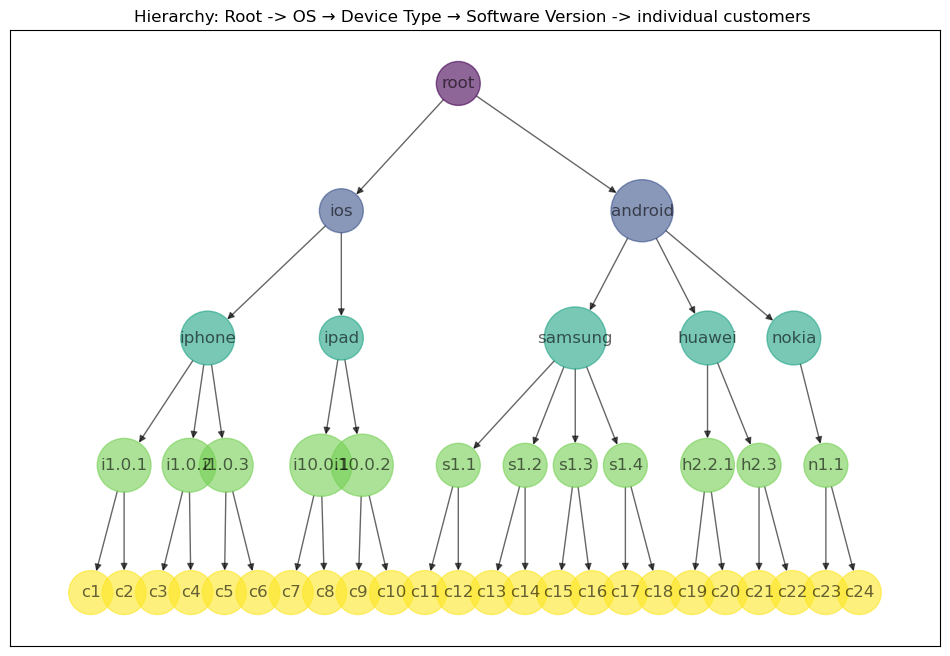

In [1]:
import matplotlib.pyplot as plt
from lib.visualizations import HierarchicalGraphViz
from lib.data_helper_utilities import nodes_list, edges_list, nodes_colors

HierarchicalGraphViz(nodes_list, edges_list, nodes_colors)
plt.title('Hierarchy: Root -> OS → Device Type → Software Version -> individual customers ')
plt.show()

## Conclusion 
First, based on our exploratory data analysis, we generate some simulated data and train a bayesian model on the simulated data. Once you're happy with the results generated on the simulated data, you train the model on actual data. If you notice the model gets stuck in some bad regions of the paramater space, or takes a long time to converge or has divergences etc, you have a problem. It means you perhaps you didn't understand the data generating mechanism and need to tweak your data simulation pipeline or change your priors/distributions and re-train the model on simulated data followed by training on actual data. 


---

← [Part 1: A Probabilistic Framework](../bayesian-modelling-part-1/index.html) · [Part 3: Building the Hierarchical Model in Stan](../bayesian-modelling-part-3/index.html) →